<a href="https://colab.research.google.com/github/findingtripti/fake-news-detection/blob/main/Fake_News_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

#Load + Label + Merge + Shuffle
fake_df = pd.read_csv("Fake.csv", on_bad_lines='skip', engine='python')
real_df = pd.read_csv("True.csv", on_bad_lines='skip', engine='python')
fake_df["label"] = 0
real_df["label"] = 1
df = pd.concat([fake_df, real_df], axis=0)
df = df.sample(frac=1).reset_index(drop=True)
df.drop_duplicates(inplace=True)
print("Fake shape:", fake_df.shape, "Real shape:", real_df.shape)


#Preprocessing
df["text"] = df["text"].str.lower()

def remove_urls(text):
    return re.sub(r"http\S+|www\S+", "", text)
df["text"] = df["text"].apply(remove_urls)

def remove_html_tags(text):
    return re.sub(r"<.*?>", "", text)
df["text"] = df["text"].apply(remove_html_tags)

def remove_punctuation(text):
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
df["text"] = df["text"].apply(remove_punctuation)

def remove_numbers(text):
    return re.sub(r"\d+", "", text)
df["text"] = df["text"].apply(remove_numbers)

stop_words = set(stopwords.words('english'))
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)
df["text"] = df["text"].apply(remove_stopwords)

def tokenize_text(text):
    return word_tokenize(text)
df["tokens"] = df["text"].apply(tokenize_text)

lemmatizer = WordNetLemmatizer()
def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]
df["tokens"] = df["tokens"].apply(lemmatize_tokens)

df["clean_text"] = df["tokens"].apply(lambda x: " ".join(x))
df["clean_text"] = df["clean_text"].fillna("").astype(str)

print("Preprocessing done! Shape:", df.shape)

# Feature Engineering
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = tfidf.fit_transform(df["clean_text"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train/test split done:", X_train.shape, X_test.shape)

#Train all 5 models
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_predictions))

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_predictions = nb_model.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_predictions))

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_predictions))

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))

svm_model = LinearSVC(max_iter=2000)
svm_model.fit(X_train, y_train)
svm_predictions = svm_model.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, svm_predictions))

print("\nAll models trained successfully! Ready for error analysis.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Fake shape: (23481, 5) Real shape: (21417, 5)
Preprocessing done! Shape: (44689, 7)
Train/test split done: (35751, 5000) (8938, 5000)
Logistic Regression Accuracy: 0.9873573506377266
Naive Bayes Accuracy: 0.9441709554710226
Decision Tree Accuracy: 0.9970910718281495
Random Forest Accuracy: 0.9982098903557843
SVM Accuracy: 0.9954128440366973

All models trained successfully! Ready for error analysis.


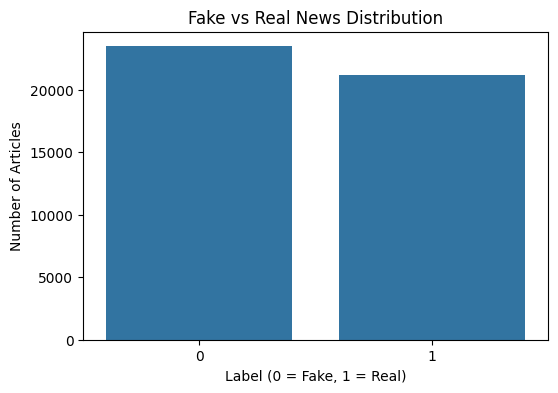

In [2]:
# using matplotlib for visualization and seaborn
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(x="label", data=df)
plt.title("Fake vs Real News Distribution")
plt.xlabel("Label (0 = Fake, 1 = Real)")
plt.ylabel("Number of Articles")
plt.show()

In [3]:
# EDA

df["label"].value_counts()

,count
label,
0,23478
1,21211


In [4]:
# calculating article length
df["text_length"] = df["clean_text"].apply(lambda x: len(str(x).split()))
df.groupby("label")["text_length"].mean()

,text_length
label,
0,236.991439
1,229.073358


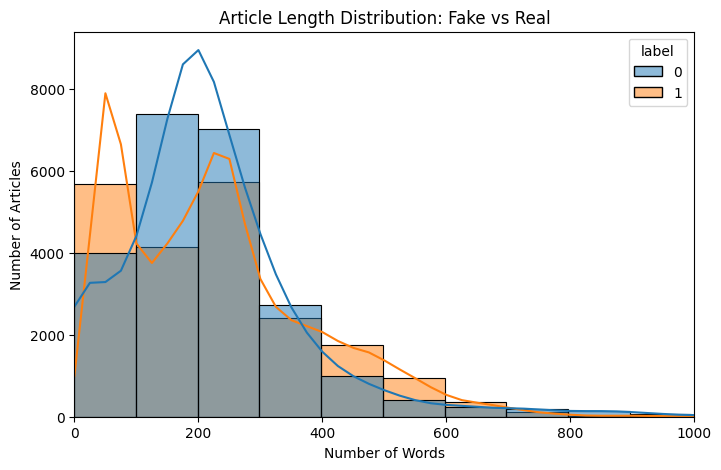

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="text_length", hue="label", bins=50, kde=True)
plt.title("Article Length Distribution: Fake vs Real")
plt.xlabel("Number of Words")
plt.ylabel("Number of Articles")
plt.xlim(0, 1000)  # bahut lambe outlier articles ko chart se temporarily hata rahe hain, taaki main pattern clearly dikhe
plt.show()

In [6]:
# most common words in real and fake article
from collections import Counter

# NaN values ko empty string mein convert karo,
df["clean_text"] = df["clean_text"].fillna("").astype(str)

# ab safely join kar sakte hain
fake_words = " ".join(df[df["label"]==0]["clean_text"]).split()
real_words = " ".join(df[df["label"]==1]["clean_text"]).split()

fake_word_freq = Counter(fake_words)
real_word_freq = Counter(real_words)

print("Top 20 words in FAKE news:")
print(fake_word_freq.most_common(20))

print("\nTop 20 words in REAL news:")
print(real_word_freq.most_common(20))

Top 20 words in FAKE news:
[('trump', 80019), ('said', 33762), ('president', 28390), ('people', 26676), ('one', 25441), ('u', 24516), ('state', 23665), ('would', 23565), ('clinton', 19857), ('time', 19198), ('year', 19074), ('obama', 18833), ('like', 18667), ('american', 18124), ('donald', 17789), ('republican', 16756), ('say', 15783), ('also', 15420), ('right', 14863), ('news', 14662)]

Top 20 words in REAL news:
[('said', 97867), ('trump', 54119), ('u', 46542), ('state', 37231), ('would', 31249), ('reuters', 28667), ('president', 28416), ('republican', 22866), ('year', 22355), ('government', 19681), ('house', 16877), ('new', 16758), ('also', 15754), ('united', 15368), ('people', 15158), ('party', 15101), ('election', 14603), ('official', 14406), ('told', 14072), ('country', 13972)]


In [7]:
!pip install wordcloud

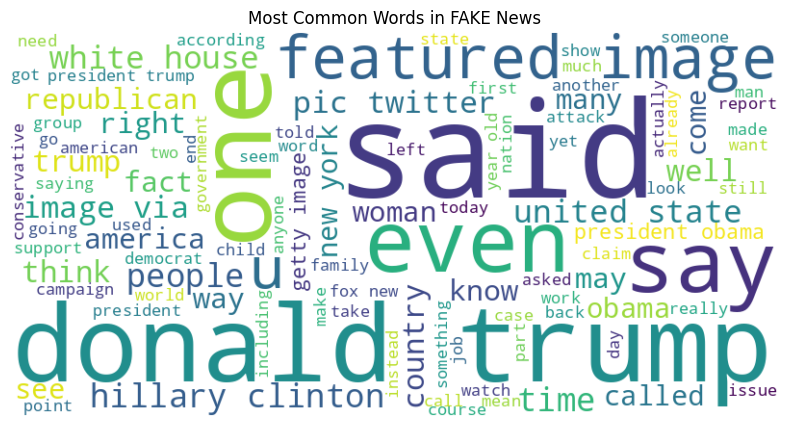

In [8]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# WordCloud ko ek single string chahiye, list nahi, isliye wapas jodte hain
fake_text = " ".join(fake_words)

# WordCloud object
wordcloud_fake = WordCloud(
    width=800, height=400,
    background_color="white",
    max_words=100          # sirf top 100 words
).generate(fake_text)

# display
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_fake, interpolation="bilinear")
plt.axis("off")   # x/y axis numbers hata do, unka koi matlab nahi yahan
plt.title("Most Common Words in FAKE News")
plt.show()

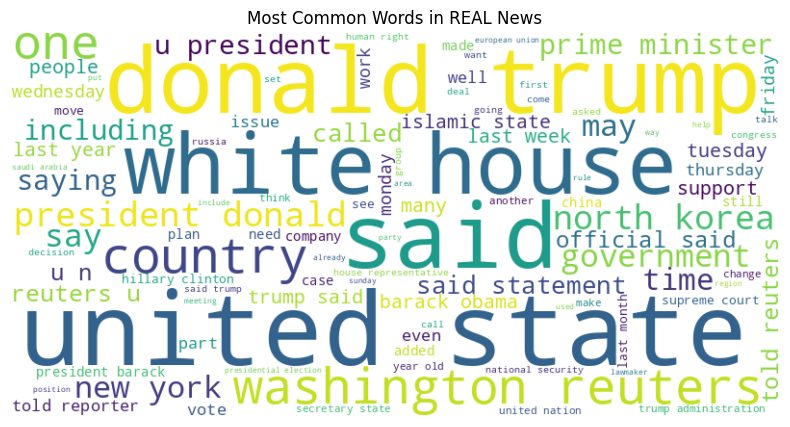

In [9]:
real_text = " ".join(real_words)

wordcloud_real = WordCloud(
    width=800, height=400,
    background_color="white",
    max_words=100
).generate(real_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_real, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in REAL News")
plt.show()

===== Logistic Regression =====
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4696
        Real       0.98      0.99      0.99      4242

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



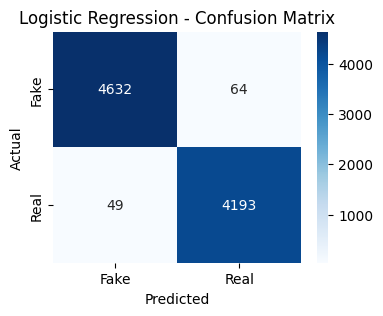

===== Naive Bayes =====
              precision    recall  f1-score   support

        Fake       0.94      0.95      0.95      4696
        Real       0.94      0.94      0.94      4242

    accuracy                           0.94      8938
   macro avg       0.94      0.94      0.94      8938
weighted avg       0.94      0.94      0.94      8938



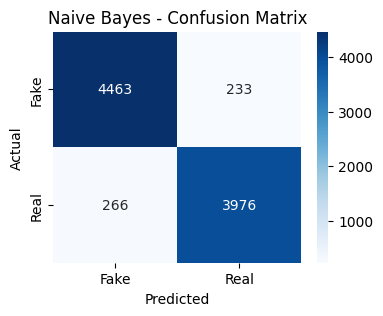

===== Decision Tree =====
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4696
        Real       1.00      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



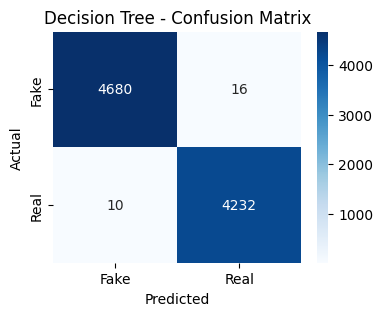

===== Random Forest =====
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4696
        Real       1.00      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



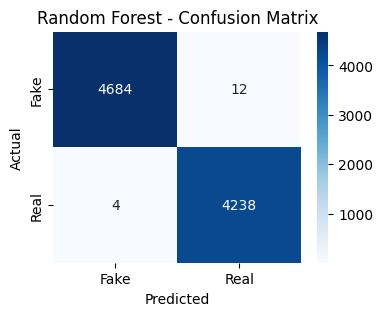

===== SVM =====
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4696
        Real       1.00      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



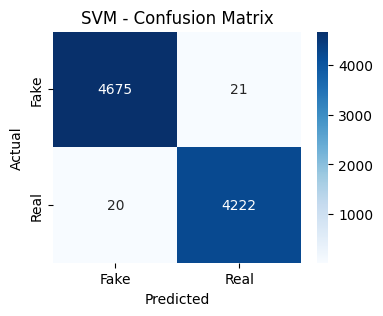

In [10]:
#model evaluation using confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model_name, y_test, predictions):
    print(f"===== {model_name} =====")

    # classification_report,precision, recall, f1-score, accuracy
    print(classification_report(y_test, predictions, target_names=["Fake", "Real"]))

    # confusion matrix visualization
    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
    plt.title(f"{model_name} - Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

evaluate_model("Logistic Regression", y_test, lr_predictions)
evaluate_model("Naive Bayes", y_test, nb_predictions)
evaluate_model("Decision Tree", y_test, dt_predictions)
evaluate_model("Random Forest", y_test, rf_predictions)
evaluate_model("SVM", y_test, svm_predictions)


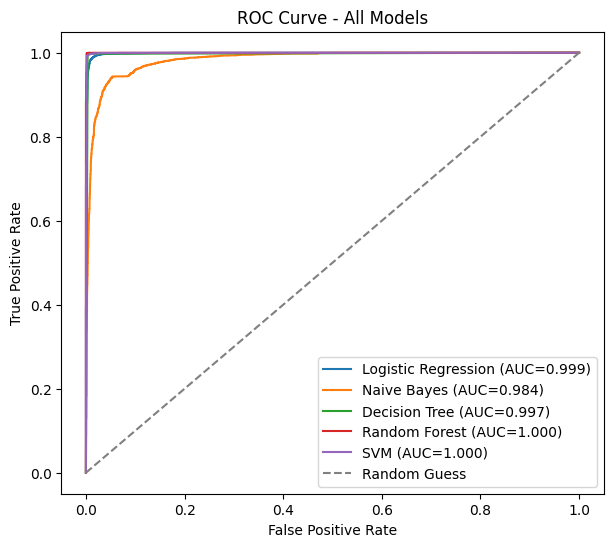

In [11]:
#roc-auc
from sklearn.metrics import roc_auc_score, roc_curve

models_dict = {
    "Logistic Regression": lr_model,
    "Naive Bayes": nb_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
}

plt.figure(figsize=(7,6))

for name, model in models_dict.items():

    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

y_score_svm = svm_model.decision_function(X_test)
auc_svm = roc_auc_score(y_test, y_score_svm)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC={auc_svm:.3f})")

plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - All Models")
plt.legend()
plt.show()

In [12]:
#cross validation by using k fold cross validation
from sklearn.model_selection import cross_val_score

# har model ke liye 5-fold cross-validation
models_to_check = {
    "Logistic Regression": lr_model,
    "Naive Bayes": nb_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "SVM": svm_model
}

for name, model in models_to_check.items():

    # scoring="accuracy" : accuracy metric
    scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")

    print(f"{name}:")
    print(f"  Fold-wise scores: {scores}")
    print(f"  Average Accuracy: {scores.mean():.4f}")
    print(f"  Standard Deviation: {scores.std():.4f}")
    print()

Logistic Regression:
  Fold-wise scores: [0.98959499 0.98914746 0.98545536 0.98925934 0.9881392 ]
  Average Accuracy: 0.9883
  Standard Deviation: 0.0015

Naive Bayes:
  Fold-wise scores: [0.94562542 0.94618483 0.9432759  0.94506601 0.9422625 ]
  Average Accuracy: 0.9445
  Standard Deviation: 0.0015

Decision Tree:
  Fold-wise scores: [0.99686731 0.99574849 0.99563661 0.99686731 0.99641938]
  Average Accuracy: 0.9963
  Standard Deviation: 0.0005

Random Forest:
  Fold-wise scores: [0.99888118 0.99798613 0.99809801 0.99798613 0.99776211]
  Average Accuracy: 0.9981
  Standard Deviation: 0.0004

SVM:
  Fold-wise scores: [0.99552473 0.99440591 0.99429403 0.99563661 0.99474096]
  Average Accuracy: 0.9949
  Standard Deviation: 0.0006



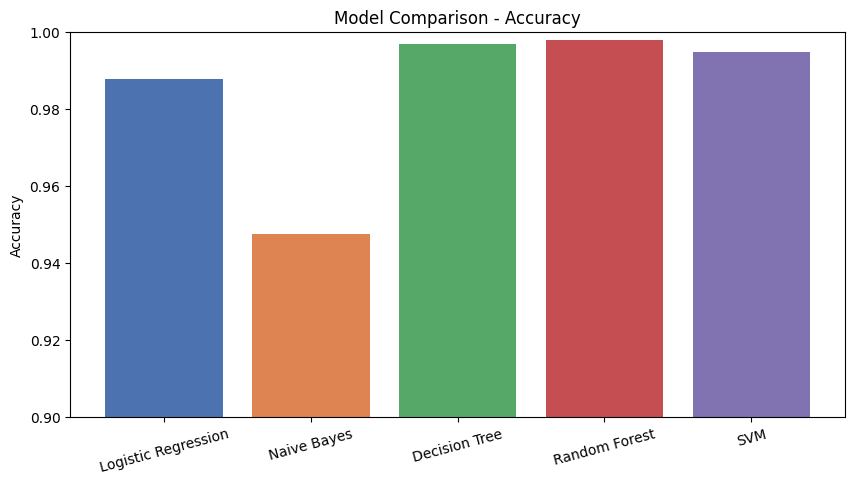

In [13]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Naive Bayes', 'Decision Tree', 'Random Forest', 'SVM']
accuracies = [0.988, 0.9477, 0.997, 0.998, 0.995]

plt.figure(figsize=(10,5))
plt.bar(models, accuracies, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2'])
plt.ylim(0.9, 1.0)
plt.ylabel("Accuracy")
plt.title("Model Comparison - Accuracy")
plt.xticks(rotation=15)
plt.show()

In [14]:
wrong_predictions_mask = (rf_predictions != y_test.values)
wrong_indices = y_test.index[wrong_predictions_mask]
wrong_examples = df.loc[wrong_indices, ["clean_text", "label"]].copy()
wrong_examples["predicted"] = rf_predictions[wrong_predictions_mask]

pd.set_option('display.max_colwidth', 150)
print(wrong_examples)

                                                                                                                                                  clean_text  \
23839  charlotte north carolina donald trump promise revive small town america face tough challenge economy decade wired direct income opportunity toward...   
19728                                                                                                                                                          
7023   like one big slush fund hillary clinton collected million foreign donor also rake million taxpayer dollar really outrageous clinton foundation maj...   
35210  u government spends billion year fight global warming crisis twice much spends protecting border put perspective every minute going global warming...   
19957  apparently take one american student destroy unity north korea north korea detained u university student third western citizen known held isolated...   
33769  apparently take one american stud

In [15]:
print("Total wrong predictions:", len(wrong_examples))
print(wrong_examples[["label", "predicted"]])

Total wrong predictions: 16
       label  predicted
23839      1          0
19728      1          0
7023       0          1
35210      0          1
19957      0          1
33769      0          1
9121       0          1
29086      0          1
11912      0          1
31268      0          1
21604      0          1
32218      0          1
43848      0          1
15171      1          0
6010       0          1
32839      1          0


In [16]:
available_indices = [idx for idx in [48141, 29871] if idx in df.index]

duplicate_check = df.loc[
    available_indices,
    ["title", "text", "clean_text", "label"]
]

pd.set_option('display.max_colwidth', 300)

print(duplicate_check)

                                                                                                                title  \
29871  CNN CUTS FEED Of CONGRESSMAN As Soon As He Speaks About Refugee Crime…Anchor Claims It’s “TV Gremlins” [Video]   

      text clean_text  label  
29871                      0  


In [17]:
#hyperparameter tuning
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 30]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best parameters found: {'max_depth': None, 'n_estimators': 200}
Best cross-validation accuracy: 0.9975385303907583


In [18]:
#models save
import joblib

# trained Random Forest model save
joblib.dump(rf_model, "fake_news_model.pkl")

# TF-IDF vectorizer also save
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model aur vectorizer successfully saved!")

Model aur vectorizer successfully saved!
